# Forward-Risk-Manager: Intensive Colab T4 Runbook

This notebook runs the full GPU-heavy workflow end-to-end:
1. Environment and GPU checks
2. Drive mount and repo sync
3. Dependency install + editable package install + tests
4. Build/train/benchmark/sweep (+ optional sweep promotion + retrain)
5. Goodness backtest + constrained scenarios + stress test
6. Hallucination calibration + diagnostics
7. Artifact bundle export and download


## 1) Runtime Setup

In Colab:
- Runtime -> Change runtime type -> Hardware accelerator: `GPU`
- Prefer `T4` and high-RAM runtime when available


In [ ]:
import os
import subprocess
import sys

# CUDA/runtime friendliness
os.environ.setdefault('PYTHONUNBUFFERED', '1')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'max_split_size_mb:256')

print('python:', sys.version)

try:
    import torch
except Exception as exc:
    raise RuntimeError('PyTorch is required in Colab runtime.') from exc

print('torch:', torch.__version__)
print('cuda_available:', torch.cuda.is_available())
print('cuda_version:', torch.version.cuda)

try:
    print(subprocess.check_output(['nvidia-smi', '-L'], text=True))
except Exception as exc:
    print('nvidia-smi unavailable:', exc)

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available. Enable GPU runtime and rerun.')

gpu_name = torch.cuda.get_device_name(0)
print('gpu:', gpu_name)
if 'T4' not in gpu_name.upper():
    print('WARNING: GPU is not T4. Notebook still works; timings will differ.')

# Throughput-friendly settings for T4
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True


python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
torch: 2.9.0+cu128
cuda_available: True
cuda_version: 12.8
GPU 0: Tesla T4 (UUID: GPU-2b2da370-9952-a331-0f65-4fc3152a2a47)

gpu: Tesla T4


## 2) Mount Drive And Open Repo


In [ ]:
from pathlib import Path
import os
import subprocess

from google.colab import drive

drive.mount('/content/drive', force_remount=False)

REPO_DIR = '/content/drive/MyDrive/Forward-Risk-Manager'
if not Path(REPO_DIR).exists():
    raise FileNotFoundError(f'Repo not found: {REPO_DIR}')

%cd $REPO_DIR
print('cwd:', os.getcwd())

if Path('.git').exists():
    print(subprocess.check_output(['git', 'status', '--short'], text=True)[:4000])
else:
    print('No .git directory found. Running from copied folder is fine.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Forward-Risk-Manager
cwd: /content/drive/MyDrive/Forward-Risk-Manager
D  .gitignore
D  README.md
D  configs/baseline.toml
D  configs/default.toml
D  configs/long_alltickers.toml
D  configs/long_constituents.toml
D  configs/train_long_alltickers.toml
D  configs/train_long_constituents.toml
D  notebooks/colab_setup.ipynb
D  pyproject.toml
D  reports/benchmark.csv
D  reports/benchmark.png
D  reports/benchmark_speed_sep.png
D  reports/ff_sweep.csv
D  reports/ff_sweep_pareto.png
D  reports/ff_sweep_summary.txt
D  reports/ff_sweep_tradeoff.png
D  reports/ff_train.csv
D  reports/ff_train.png
D  reports/ff_train_long_constituents.csv
D  reports/ff_train_long_constituents.png
D  reports/goodness_backtest.csv
D  reports/goodness_quantiles.csv
D  reports/goodness_scatter.png
D  reports/hallucination_calibration.json
D  reports/hallucination_diagno

## 3) Install Dependencies And Verify Tests


In [ ]:
import shlex
import subprocess
import sys

PYTHON = shlex.quote(sys.executable)

commands = [
    f"{PYTHON} -m pip install --upgrade pip",
    f"{PYTHON} -m pip install -r requirements.txt",
    f"{PYTHON} -m pip install pytest",
    # --no-build-isolation avoids unnecessary build-dep fetches in constrained environments
    f"{PYTHON} -m pip install -e . --no-build-isolation",
    f"{PYTHON} -m pytest -q",
]

for cmd in commands:
    print('+', cmd)
    subprocess.run(cmd, shell=True, check=True)

print('Dependency + test setup complete.')


+ /usr/bin/python3 -m pip install --upgrade pip
+ /usr/bin/python3 -m pip install -r requirements.txt
+ /usr/bin/python3 -m pip install pytest
+ /usr/bin/python3 -m pip install -e . --no-build-isolation
+ /usr/bin/python3 -m pytest -q
Dependency + test setup complete.


## 4) Intensive Session Controls


In [ ]:
from pathlib import Path
import tomllib

# Base configs
BUILD_CONFIG = 'configs/long_constituents.toml'
TRAIN_CONFIG = 'configs/train_long_constituents.toml'
SWEEP_SECTION = 'sweep'
DEVICE = 'cuda'

# Override train epochs at runtime for a deeper Colab pass
TRAIN_EPOCHS_OVERRIDE = 240

# Pipeline toggles
RUN_MERGE_RAW = False
RUN_BUILD = True
RUN_TRAIN = True
RUN_BENCHMARK = True
RUN_SWEEP = True
RUN_SWEEP_SUMMARY = True
RUN_PLOT_SWEEP = True
RUN_PROMOTE_SWEEP = True
RUN_RETRAIN_AFTER_PROMOTE = True
RUN_REBENCHMARK_AFTER_PROMOTE = True
RUN_GOODNESS_BACKTEST = True
RUN_SCENARIO_BOOK = True
RUN_STRESS_TEST_REPORT = True
RUN_HALLUCINATION_CALIBRATION = True
RUN_PLOT_HALLUCINATION = True
RUN_HALLUCINATION_DIAGNOSTICS = True
RUN_EXPORT_ARTIFACTS = True

ALLOW_OPTIONAL_FAILURES = True

# Optional data prep
RAW_ROOT = 'data/raw'
MERGED_RAW_DIR = 'data/raw_merged'

# Sweep promotion
SWEEP_CSV = 'reports/ff_sweep.csv'
PROMOTE_SWEEP_RANK_BY = 'auto'   # auto | score | eval_sep | eval_acc | graphs_per_s
PROMOTE_SWEEP_MODE = ''          # e.g. 'ff_e2e' or ''
PROMOTE_SWEEP_APPLY_MODE = True

# Goodness backtest
BACKTEST_TICKER = 'MDY'
BACKTEST_HORIZONS = '5,21'
BACKTEST_MAX_ABS_LOGRET = 0.35

# Scenario generation (exact-target constraints)
SCENARIO_TICKER = 'MDY'
SCENARIO_FALLBACK_TICKER = 'MDY'
SCENARIO_NUM = 100
SCENARIO_TARGET_DROP = -0.10
SCENARIO_CONSTRAINT_WEIGHT = 25.0
SCENARIO_CONSTRAINT_MODE = 'exact'       # exact | at_least
SCENARIO_CONSTRAINT_TOLERANCE = 0.01
SCENARIO_TARGET_TOLERANCE = 0.01
SCENARIO_TARGET_HIT_RATE = 0.75
SCENARIO_MAX_ADAPT_STEPS = 10

# Artifacts
ARTIFACT_BUNDLE = 'reports/colab_intensive_bundle.zip'

for p in [BUILD_CONFIG, TRAIN_CONFIG]:
    if not Path(p).exists():
        raise FileNotFoundError(p)

with Path(TRAIN_CONFIG).open('rb') as f:
    cfg = tomllib.load(f)

print('build config:', BUILD_CONFIG)
print('train config:', TRAIN_CONFIG)
print('train.neg_mode:', cfg.get('train', {}).get('neg_mode', 'n/a'))
print('train.goodness_target:', cfg.get('train', {}).get('goodness_target', 'n/a'))
print('train.self_contrastive_temp:', cfg.get('train', {}).get('self_contrastive_temp', 'n/a'))
print('train.distance_forward_weight:', cfg.get('train', {}).get('distance_forward_weight', 'n/a'))


build config: configs/long_constituents.toml
train config: configs/train_long_constituents.toml
train.neg_mode: self_contrastive
train.goodness_target: 3.630000000000001
train.self_contrastive_temp: 0.2
train.distance_forward_weight: 0.05


## 5) Helpers


In [ ]:
import os
import shlex
import subprocess
import sys
import time
from pathlib import Path

PYTHON = shlex.quote(sys.executable)


def q(s: str) -> str:
    return shlex.quote(str(s))


def run(cmd: str, allow_fail: bool = False) -> bool:
    print()
    print('=' * 100)
    print(cmd)
    print('=' * 100)
    t0 = time.time()

    env = os.environ.copy()
    env.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

    p = subprocess.Popen(
        cmd,
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )
    assert p.stdout is not None
    for line in p.stdout:
        print(line, end='')
    rc = p.wait()

    dt = time.time() - t0
    if rc != 0:
        msg = f'Command failed ({rc}): {cmd}'
        if allow_fail:
            print('WARNING:', msg)
            return False
        raise RuntimeError(msg)

    print(f'Completed in {dt / 60:.2f} min')
    return True


def choose_scenario_ticker(train_config_path: str, requested: str, fallback: str) -> str:
    req = (requested or '').strip().upper()
    fb = (fallback or '').strip().upper()

    import tomllib
    import torch

    with Path(train_config_path).open('rb') as f:
        cfg = tomllib.load(f)
    graphs_path = Path(cfg.get('train', {}).get('graphs', ''))
    if not graphs_path.exists():
        return req or fb

    try:
        payload = torch.load(graphs_path, map_location='cpu', weights_only=False)
    except TypeError:
        payload = torch.load(graphs_path, map_location='cpu')

    tickers_list = payload.get('tickers', []) if isinstance(payload, dict) else []
    ticker_set = {t for tickers in tickers_list for t in tickers}
    if not ticker_set:
        return req or fb

    if req and req in ticker_set:
        return req
    if fb and fb in ticker_set:
        print(f'[scenario_book] {req or requested} not found. Using fallback {fb}.')
        return fb

    first = sorted(ticker_set)[0]
    print(f'[scenario_book] {req or requested} not found. Using {first}.')
    return first


## 6) Run Full Intensive Pipeline


In [ ]:
if RUN_MERGE_RAW:
    run(f"{PYTHON} scripts/merge_raw_years.py --raw-root {q(RAW_ROOT)} --out-dir {q(MERGED_RAW_DIR)}")

if RUN_BUILD:
    run(f"{PYTHON} scripts/build_graphs.py --config {q(BUILD_CONFIG)}")

train_cmd = f"{PYTHON} scripts/train_ff_gnn.py --config {q(TRAIN_CONFIG)} --device {q(DEVICE)}"
if TRAIN_EPOCHS_OVERRIDE and int(TRAIN_EPOCHS_OVERRIDE) > 0:
    train_cmd += f" --epochs {int(TRAIN_EPOCHS_OVERRIDE)}"

if RUN_TRAIN:
    run(train_cmd)

if RUN_BENCHMARK:
    run(f"{PYTHON} scripts/benchmark_training.py --config {q(TRAIN_CONFIG)}")

if RUN_SWEEP:
    run(f"{PYTHON} scripts/ff_sweep.py --config {q(TRAIN_CONFIG)} --section {q(SWEEP_SECTION)}")

if RUN_SWEEP_SUMMARY:
    run(f"{PYTHON} scripts/ff_sweep_summary.py --csv {q(SWEEP_CSV)}")

if RUN_PLOT_SWEEP:
    run(f"{PYTHON} scripts/plot_ff_sweep.py --csv {q(SWEEP_CSV)}")

if RUN_PROMOTE_SWEEP:
    mode_arg = f" --mode {q(PROMOTE_SWEEP_MODE)}" if PROMOTE_SWEEP_MODE else ""
    apply_mode_arg = '--apply-mode' if PROMOTE_SWEEP_APPLY_MODE else '--no-apply-mode'
    run(
        f"{PYTHON} scripts/promote_sweep_best.py --config {q(TRAIN_CONFIG)} "
        f"--csv {q(SWEEP_CSV)} --rank-by {q(PROMOTE_SWEEP_RANK_BY)} "
        f"{apply_mode_arg}{mode_arg} --apply"
    )

    if RUN_RETRAIN_AFTER_PROMOTE:
        run(train_cmd)
        if RUN_REBENCHMARK_AFTER_PROMOTE:
            run(f"{PYTHON} scripts/benchmark_training.py --config {q(TRAIN_CONFIG)}")

if RUN_GOODNESS_BACKTEST:
    run(
        f"{PYTHON} scripts/goodness_backtest.py --config {q(TRAIN_CONFIG)} "
        f"--ticker {q(BACKTEST_TICKER)} --horizons {q(BACKTEST_HORIZONS)} "
        f"--max-abs-logret {float(BACKTEST_MAX_ABS_LOGRET)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

scenario_ticker = choose_scenario_ticker(TRAIN_CONFIG, SCENARIO_TICKER, SCENARIO_FALLBACK_TICKER)

if RUN_SCENARIO_BOOK:
    run(
        f"{PYTHON} scripts/scenario_book.py --config {q(TRAIN_CONFIG)} "
        f"--num-scenarios {int(SCENARIO_NUM)} "
        f"--target-ticker {q(scenario_ticker)} "
        f"--target-drop {float(SCENARIO_TARGET_DROP)} "
        f"--constraint-weight {float(SCENARIO_CONSTRAINT_WEIGHT)} "
        f"--constraint-mode {q(SCENARIO_CONSTRAINT_MODE)} "
        f"--constraint-tolerance {float(SCENARIO_CONSTRAINT_TOLERANCE)} "
        f"--target-tolerance {float(SCENARIO_TARGET_TOLERANCE)} "
        f"--target-hit-rate {float(SCENARIO_TARGET_HIT_RATE)} "
        f"--max-adapt-steps {int(SCENARIO_MAX_ADAPT_STEPS)} "
        f"--adaptive "
        f"--diag-out reports/scenario_constraint_diagnostics.csv",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_STRESS_TEST_REPORT:
    run(
        f"{PYTHON} scripts/stress_test_report.py --csv reports/scenario_book.csv "
        f"--target-ticker {q(scenario_ticker)}",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_HALLUCINATION_CALIBRATION:
    run(
        f"{PYTHON} scripts/hallucination_calibration.py --csv reports/scenario_book.csv "
        f"--target-ticker {q(scenario_ticker)} "
        f"--out-by-ticker reports/hallucination_calibration_by_ticker.csv",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_PLOT_HALLUCINATION:
    run(
        f"{PYTHON} scripts/plot_hallucination.py --config {q(TRAIN_CONFIG)} "
        f"--save-csv-all reports/hallucination_window_all.csv",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_HALLUCINATION_DIAGNOSTICS:
    run(
        f"{PYTHON} scripts/plot_hallucination_diagnostics.py --csv reports/hallucination_window_all.csv",
        allow_fail=ALLOW_OPTIONAL_FAILURES,
    )

if RUN_EXPORT_ARTIFACTS:
    run(
        f"zip -r {q(ARTIFACT_BUNDLE)} reports runs -x 'runs/cache/*'",
        allow_fail=True,
    )

print('Intensive pipeline finished.')



/usr/bin/python3 scripts/build_graphs.py --config configs/long_constituents.toml
Membership ffill: source_dates=2659 filled_dates=1486 gap_dropped=134 max_gap_days=63

Building graphs: 100%|██████████| 3665/3665 [01:16<00:00, 47.90win/s]
Wrote data/processed_long/graphs_constituents.pt with 3531 graphs
Date range: 2011-06-28 -> 2026-02-06 | windows: 3665 | built: 3531 | skipped: members=134, cols=0, min_nodes=0, no_edges=0
[W210 18:46:28.509407713 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
Completed in 2.48 min

/usr/bin/python3 scripts/train_ff_gnn.py --config configs/train_long_constituents.toml --device cuda --epochs 240
adaptive_goodness_target disabled for self_contrastive mode.
device request: cuda
device: cuda
torch: 2.9.0+cu128
cuda_available: True
cuda_version: 12.8
mps_built: False
mps_available: False
cuda_device_name: Tesla T4
neg_mode: self_contrastive | batch_size: 128 | loader_workers: 0
f

## 7) Inspect Key Outputs


In [ ]:
from pathlib import Path
import pandas as pd

csvs = [
    'reports/ff_train_long_constituents.csv',
    'reports/benchmark.csv',
    'reports/ff_sweep.csv',
    'reports/scenario_constraint_diagnostics.csv',
    'reports/stress_test_report.csv',
    'reports/hallucination_calibration_by_ticker.csv',
    'reports/goodness_backtest.csv',
]

for path in csvs:
    p = Path(path)
    print()
    print('=' * 100)
    print(p)
    if not p.exists():
        print('missing')
        continue
    df = pd.read_csv(p)
    print('shape:', df.shape)
    with pd.option_context('display.max_columns', 40):
        print(df.head(3))

print()
print('Artifacts preview (first 150 files):')
for p in sorted(Path('reports').glob('*'))[:150]:
    print(p)



reports/ff_train_long_constituents.csv
shape: (240, 17)
   epoch      loss     g_pos     g_neg  hallucinate_ratio  gate_ratio  \
0      1  2.613724  0.997738  0.439514                0.0         0.0   
1      2  2.211738  0.995990  0.266293                0.0         0.0   
2      3  2.074581  0.996359  0.227316                0.0         0.0   

   hall_hardness  hall_close_ratio  energy_penalty  risk_loss  \
0            0.0               0.0        0.016945   0.320840   
1            0.0               0.0        0.003586   0.311612   
2            0.0               0.0        0.003221   0.308470   

   dist_forward_loss  goodness_target_used  neg_mix_end_used  \
0           0.010944                 3.993              0.35   
1           0.036588                 3.993              0.35   
2           0.034501                 3.993              0.35   

   neg_gate_margin_used  hall_lr_used  hall_steps_used  \
0                   0.7          0.02                1   
1               

## 8) Preview Plots


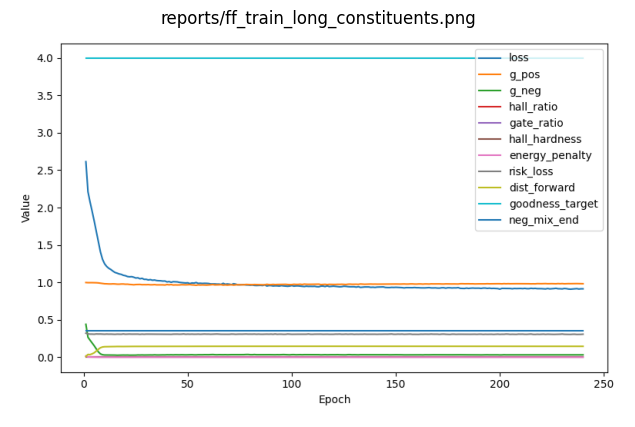

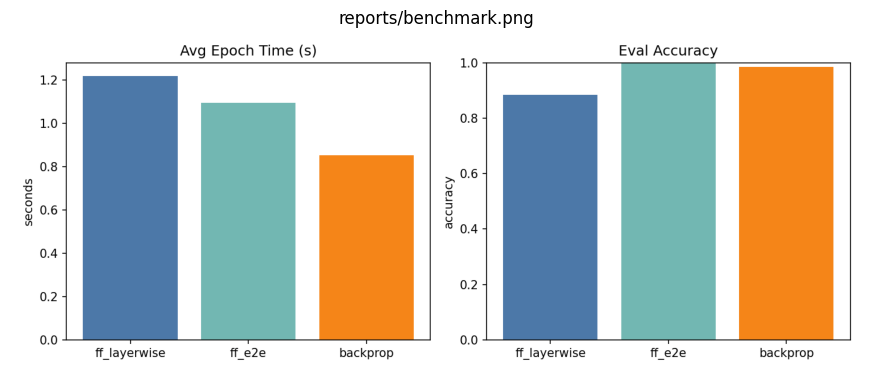

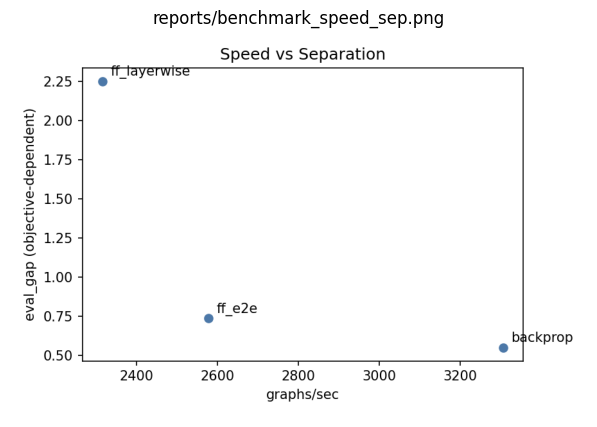

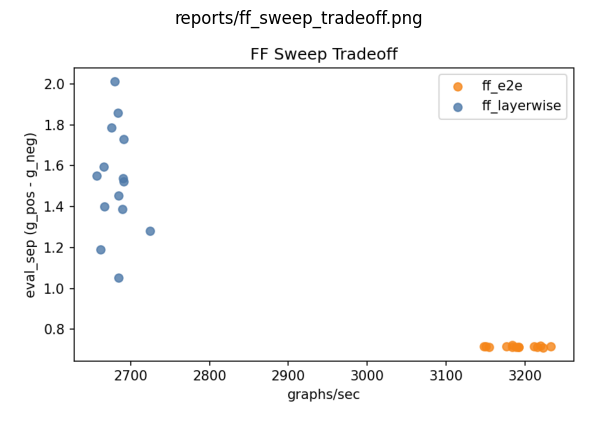

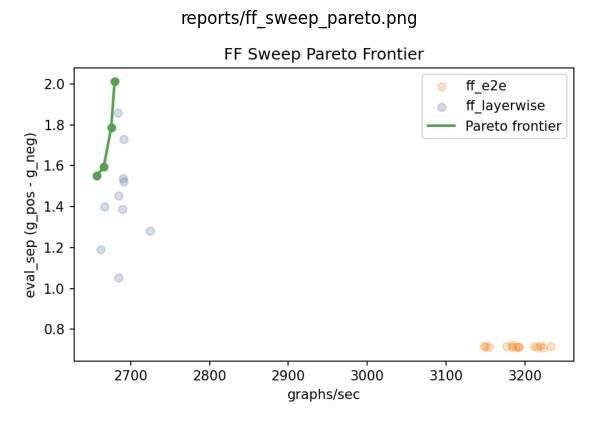

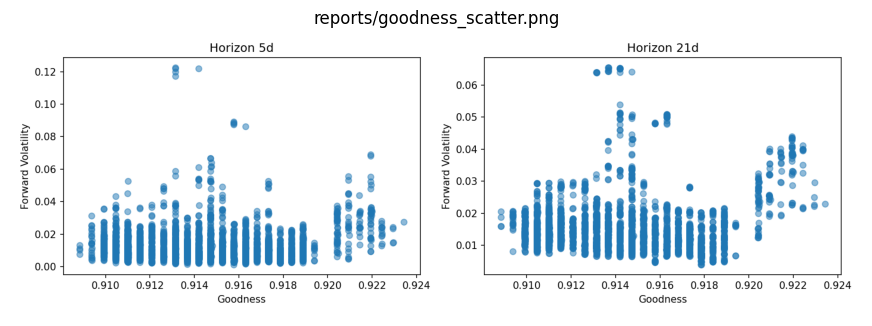

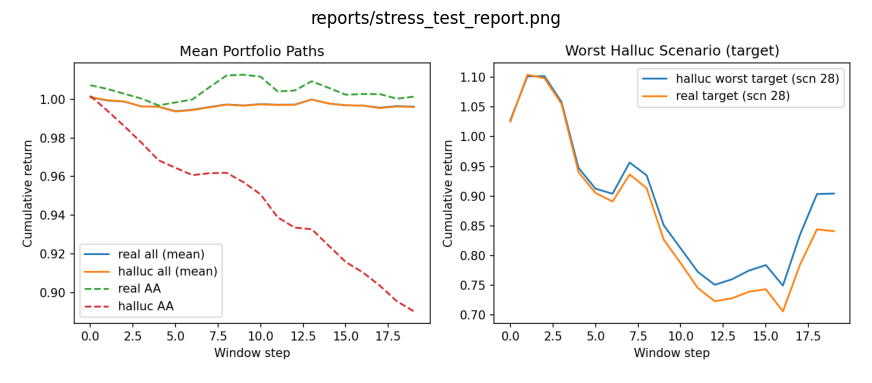

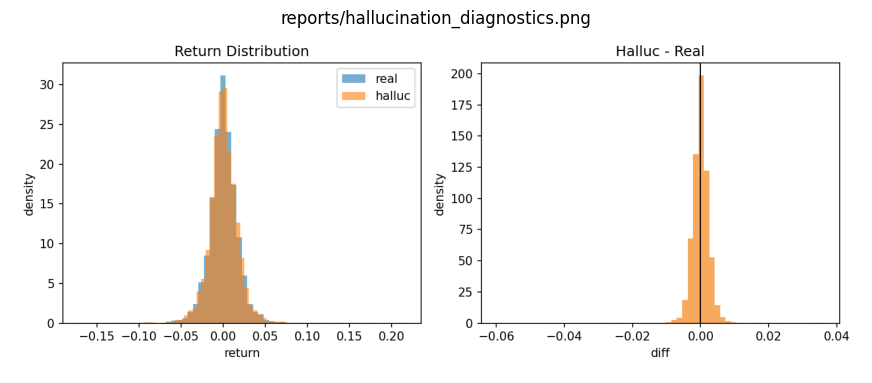

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

images = [
    'reports/ff_train_long_constituents.png',
    'reports/benchmark.png',
    'reports/benchmark_speed_sep.png',
    'reports/ff_sweep_tradeoff.png',
    'reports/ff_sweep_pareto.png',
    'reports/goodness_scatter.png',
    'reports/stress_test_report.png',
    'reports/hallucination_diagnostics.png',
]

for img_path in images:
    p = Path(img_path)
    if not p.exists():
        continue
    img = Image.open(p)
    plt.figure(figsize=(11, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(str(p))
    plt.show()


## 9) Download Artifact Bundle


In [ ]:
from pathlib import Path

bundle = Path(ARTIFACT_BUNDLE)
if bundle.exists():
    print('bundle:', bundle, 'size_mb=', round(bundle.stat().st_size / (1024 * 1024), 2))
    try:
        from google.colab import files
        files.download(str(bundle))
    except Exception as exc:
        print('Auto-download unavailable in this runtime:', exc)
else:
    print('Artifact bundle not found:', bundle)


bundle: reports/colab_intensive_bundle.zip size_mb= 10.13


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes

- This notebook is configured for a heavy Colab T4 session; long cells can run for hours.
- `RUN_PROMOTE_SWEEP=True` mutates `TRAIN_CONFIG` with promoted parameters.
- If CUDA OOM occurs, reduce batch size in `TRAIN_CONFIG` and rerun from training onward.
- Keep runtime connected during intensive runs to avoid kernel reset.
